https://www.kaggle.com/code/abhijitsingh001/mbti-test-your-personality/notebook

__Step 1: Imports and setup__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Download necessary NLTK resources incase they are not already available, reuired for text preprocessing and analysis
nltk.download(['stopwords', 'punkt', 'wordnet', 'averaged_perceptron_tagger'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nitya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nitya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nitya\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\nitya\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [3]:
# Load dataset
df = pd.read_csv('dataset.csv')  

In [4]:
print(df.head())

   type                                              posts
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...


In [5]:
print(df.shape)
print(df.dtypes)

(8675, 2)
type     str
posts    str
dtype: object


__Step 2: Basic Dataset Understanding__

In [6]:
# Basic info
print("Shape:", df.shape)

Shape: (8675, 2)


- <font color='red'>8675 Rows and 2 columns of data </font>

__Step 3: Checking for Null Values__

In [7]:
print("\nNull values:\n", df.isnull().sum())


Null values:
 type     0
posts    0
dtype: int64


- <font color='red'>Dataset does not have null values </font>

__Step 4: Checking for duplicate values__

In [8]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


- <font color='red'>Dataset does not have duplicate values </font>

__Step 5: Checking for imbalance in dataset__

In [9]:
print("\nUnique personality types:", df['type'].nunique())
print(df['type'].value_counts())


Unique personality types: 16
type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64


<font color='orange'>Above piece of code shows us the frequency of each personality type in the dataset<br>
Inferences:- <br>
- 16 unique personality types
- The dataset is imbalanced (1 type has 1832 values while 1 has only 39) 
- So model will get biased towards majority class </font>


Imbalance ratio (max/min): 46.97
Most frequent class: INFP (1832)
Least frequent class: ESTJ (39)


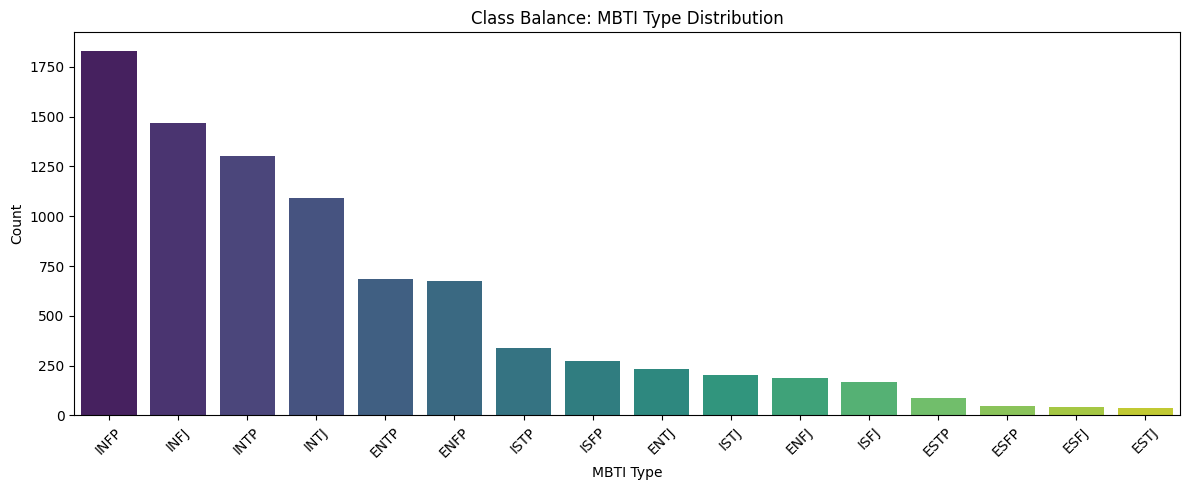

In [10]:
# class-balance check
class_counts = df['type'].value_counts()

# Imbalance ratio = largest class / smallest class
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Most frequent class: {class_counts.idxmax()} ({class_counts.max()})")
print(f"Least frequent class: {class_counts.idxmin()} ({class_counts.min()})")

# Bar plot
plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Balance: MBTI Type Distribution')
plt.xlabel('MBTI Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

__Step 6: Cleaning of Dataset__
(removing links, symbols, numbers)

In [11]:
def clean_text_basic(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)   # to remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # this will keep only letters
    text = re.sub(r'\s+', ' ', text).strip()       # this will remove extra spaces
    return text

df['cleaned_posts'] = df['posts'].apply(clean_text_basic)

print(df[['posts', 'cleaned_posts']].head(3))

                                               posts  \
0  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...   
1  'I'm finding the lack of me in these posts ver...   
2  'Good one  _____   https://www.youtube.com/wat...   

                                       cleaned_posts  
0  and intj moments sportscenter not top ten play...  
1  i m finding the lack of me in these posts very...  
2  good one course to which i say i know that s m...  


__Step 7: Normalization__ 
(removing stopwords and lemmatization) 

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['normalized_posts'] = df['cleaned_posts'].apply(normalize_text)

# quick check
print(df[['cleaned_posts', 'normalized_posts']].head(3))

                                       cleaned_posts  \
0  and intj moments sportscenter not top ten play...   
1  i m finding the lack of me in these posts very...   
2  good one course to which i say i know that s m...   

                                    normalized_posts  
0  intj moment sportscenter top ten play prank li...  
1  finding lack post alarming sex boring position...  
2  good one course say know blessing curse absolu...  


<font color='orange'>Removing stopwords reduces the size of the dataset a bit by removing filler words and lemmatization catches the root word  </font>

__Step 8: EDA of Text__

In [13]:
from collections import Counter

def add_text_stats(dataframe, text_col, prefix=''):
    out = dataframe.copy()
    col = text_col
    out[f'{prefix}char_count'] = out[col].fillna('').str.len()
    out[f'{prefix}word_count'] = out[col].fillna('').str.split().str.len()
    out[f'{prefix}unique_word_count'] = out[col].fillna('').apply(lambda s: len(set(s.split())))
    return out

def get_top_words(series, n=20):
    tokens = ' '.join(series.fillna('')).split()
    counts = Counter(tokens)
    return pd.DataFrame(counts.most_common(n), columns=['word', 'count'])

def plot_top_words(top_words_df, title='Top Words'):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_words_df, x='count', y='word', palette='viridis')
    plt.title(title)
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

- <font color='red'>Text statistics from normalized text </font>

In [14]:
df = add_text_stats(df, text_col='normalized_posts', prefix='norm_')

print(df[['norm_char_count', 'norm_word_count', 'norm_unique_word_count']].describe().round(2))

       norm_char_count  norm_word_count  norm_unique_word_count
count          8675.00          8675.00                 8675.00
mean           4009.33           603.79                  401.88
std             969.62           141.87                   83.80
min               0.00             0.00                    0.00
25%            3460.50           525.00                  358.00
50%            4174.00           630.00                  415.00
75%            4719.00           708.00                  460.00
max            6428.00           921.00                  631.00


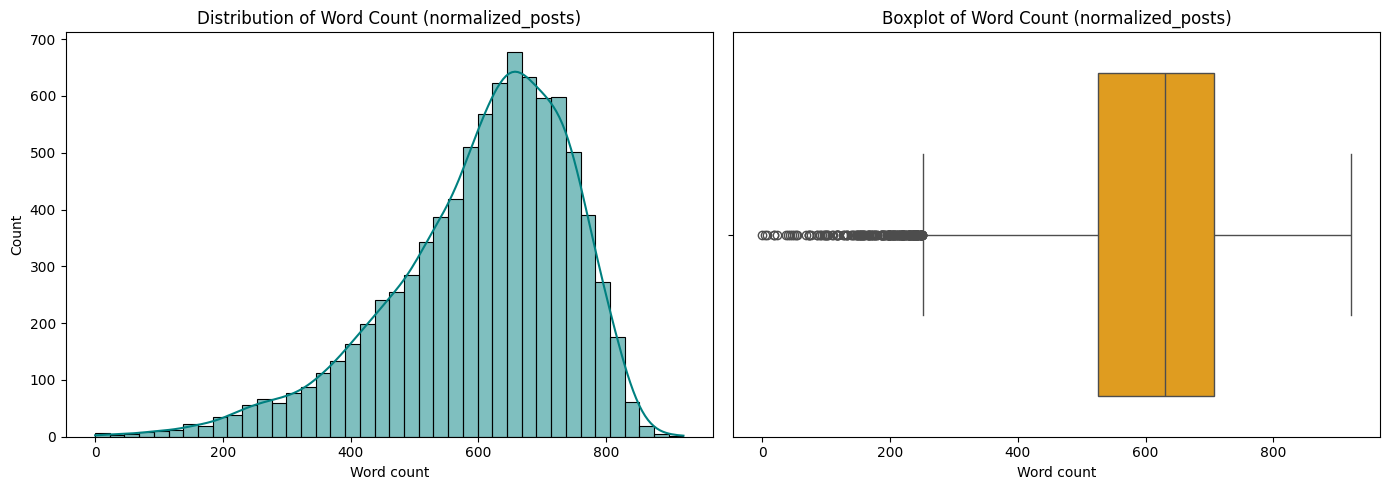

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['norm_word_count'], bins=40, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Word Count (normalized_posts)')
axes[0].set_xlabel('Word count')

sns.boxplot(x=df['norm_word_count'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot of Word Count (normalized_posts)')
axes[1].set_xlabel('Word count')

plt.tight_layout()
plt.show()

<font color='orange'>Above plots show: 
- Most posts are between 600–700 words.

- The distribution has 1 clear peak.

- It is slightly left-skewed and has more short post outliers.

- There are several short-post outliers and very few extremely long ones.

- The median word count is ~ 630 words.

- The middle 50% of posts lie roughly between 550–700 words.

- Overall range: 0 to 850–900 words.
</font>

- <font color='red'>Overall top words </font>

      word  count
0     like  71132
1    think  50983
2   people  48257
3      one  40278
4     know  38334
5   really  35293
6    would  35016
7    thing  34642
8     time  33761
9      get  33343
10    feel  25728
11    type  24145
12    make  23659
13    much  23120
14    well  22951
15     say  22726
16  friend  22206
17    love  21875
18     way  21813
19    want  21210


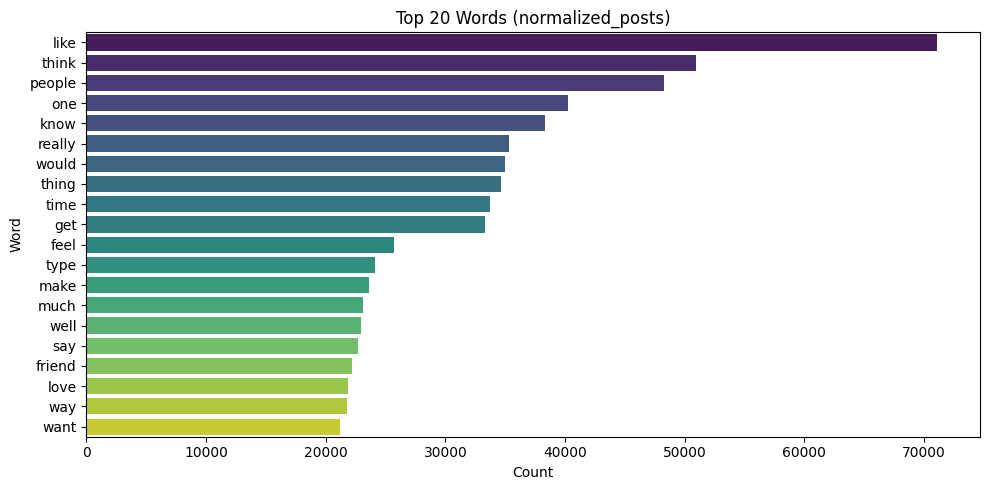

In [16]:
top_words_overall = get_top_words(df['normalized_posts'], n=20)
print(top_words_overall)
plot_top_words(top_words_overall, title='Top 20 Words (normalized_posts)')

### __CLEANED DATASET SAVED___

In [17]:
df.to_csv("clean_mbti_dataset.csv", index=False)

In [18]:
import os
os.listdir()

['.git',
 '.gitignore',
 'clean_mbti_dataset.csv',
 'dataset.csv',
 'EDA - Preprocesing.ipynb',
 'main.ipynb']